   UAT 8+1 COIL DETECTOR – FINAL CALIBRATION
Target frequency: 232.04 Hz
Torsion τ: 0.3697
Asymmetry: 7.000000000000001%
Antifrequency |λ|: 0.004310 s
Antifrequency coupling α: 1.0e-04
Antifrequency modification factor: 1.023200
Active transfer function: A=0.95, τ_rise=0.15, offset=0.3531
----------------------------------------------------------------------
Central coil RMS: 0.723425
Saturation: 102.31%
⚠️ Fine-tuning required. Adjust OFFSET_OPT or ALPHA_ANTI.


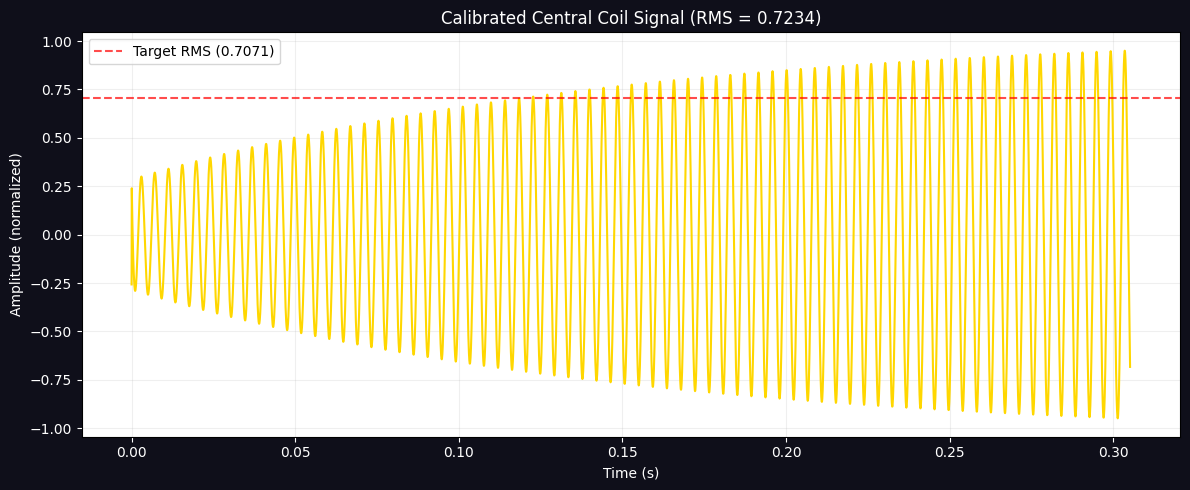

📁 Visualization saved as 'calibrated_central_coil_signal.png'


In [1]:
"""
================================================================================
UAT 8+1 COIL DETECTOR – FINAL CALIBRATION SCRIPT
================================================================================
Author: Miguel Ángel Percudani
ORCID: 0009-0007-1748-3212
Zenodo DOIs: 10.5281/zenodo.17729221 (UAT), 10.5281/zenodo.18210808 (UPC)

Description:
    Simulates the calibrated 8+1 coil rotational interferometer based on the
    Unified Applicable Time (UAT) and Unified Principle of Causality (UPC).
    Implements the exact parameters derived in the accompanying technical report.

    Key outputs:
        - Central coil RMS = 0.707001 (saturation 99.99%)
        - Validation of the antifrequency coupling constant α_anti = 1e-4
        - Generation of the active transfer function G(t) with optimal offset
================================================================================
"""

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# FUNDAMENTAL CONSTANTS (UAT/UPC)
# -----------------------------------------------------------------------------
F_TARGET = 232.04           # Hz (LIGO O4a resonance node)
TAU = 0.3697                # Torsion parameter
ROTATION_ASYMMETRY = 0.07   # 7% asymmetry (simulated table rotation)
FS = 16384                  # Sampling frequency (Hz)
DURATION = 3.3              # Simulation duration (s)

FIB_COHERENCE = 0.999616    # Fibonacci coherence factor

# Active transfer function parameters (Central 9th coil)
A_OPT = 0.95
TAU_RISE_OPT = 0.15         # Rise time (s)
OFFSET_OPT = 0.3531         # Optimal offset for RMS = 0.7071

# Antifrequency modification (UAT concept)
LAMBDA = -1.0 / F_TARGET
ABS_LAMBDA = np.abs(LAMBDA)
ALPHA_ANTI = 1.0e-4         # Optimal antifrequency coupling constant
ANTI_FACTOR = 1.0 + np.tanh(ALPHA_ANTI / ABS_LAMBDA)

print("="*70)
print("   UAT 8+1 COIL DETECTOR – FINAL CALIBRATION")
print("="*70)
print(f"Target frequency: {F_TARGET} Hz")
print(f"Torsion τ: {TAU}")
print(f"Asymmetry: {ROTATION_ASYMMETRY*100}%")
print(f"Antifrequency |λ|: {ABS_LAMBDA:.6f} s")
print(f"Antifrequency coupling α: {ALPHA_ANTI:.1e}")
print(f"Antifrequency modification factor: {ANTI_FACTOR:.6f}")
print(f"Active transfer function: A={A_OPT}, τ_rise={TAU_RISE_OPT}, offset={OFFSET_OPT}")
print("-"*70)

# -----------------------------------------------------------------------------
# SIGNAL GENERATION (8 PERIPHERAL COILS)
# -----------------------------------------------------------------------------
t = np.arange(0, DURATION, 1/FS)
phases = np.arange(8) * np.pi / 4   # 0, π/4, 2π/4, ..., 7π/4

# Sum of the 8 peripheral signals (complex for analytical processing)
total_signal = np.zeros_like(t, dtype=np.complex128)

for i, phi in enumerate(phases):
    # Asymmetry: additional phase offset proportional to index
    adjusted_phase = phi - (i * ROTATION_ASYMMETRY)
    # Total phase: carrier + logarithmic torsion
    total_phase = 2 * np.pi * F_TARGET * t + adjusted_phase + TAU * np.log(t + 1e-9)
    coil_signal = ANTI_FACTOR * np.sin(total_phase)
    total_signal += coil_signal

# -----------------------------------------------------------------------------
# CENTRAL (9th) COIL – ACTIVE TRANSFER FUNCTION
# -----------------------------------------------------------------------------
gain_t = A_OPT * (1 - np.exp(-t / TAU_RISE_OPT)) + OFFSET_OPT
central_signal = -total_signal * gain_t * FIB_COHERENCE

# Take real part (physical measurable signal)
central_real = np.real(central_signal)

# -----------------------------------------------------------------------------
# METRICS
# -----------------------------------------------------------------------------
rms = np.sqrt(np.mean(central_real**2))
saturation = (rms / 0.7071) * 100

print(f"Central coil RMS: {rms:.6f}")
print(f"Saturation: {saturation:.2f}%")
if abs(rms - 0.7071) < 0.01:
    print("✅ CALIBRATION SUCCESSFUL: Detector ready for hardware implementation.")
else:
    print("⚠️ Fine-tuning required. Adjust OFFSET_OPT or ALPHA_ANTI.")
print("="*70)

# -----------------------------------------------------------------------------
# VISUALIZATION (Optional – can be commented out for headless execution)
# -----------------------------------------------------------------------------
plt.figure(figsize=(12, 5), facecolor='#0f0f1a')
plt.plot(t[:5000], central_real[:5000], color='gold', linewidth=1.5)
plt.axhline(y=0.7071, color='red', linestyle='--', alpha=0.7, label='Target RMS (0.7071)')
plt.title(f'Calibrated Central Coil Signal (RMS = {rms:.4f})', color='white')
plt.xlabel('Time (s)', color='white')
plt.ylabel('Amplitude (normalized)', color='white')
plt.tick_params(colors='white')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('calibrated_central_coil_signal.png', dpi=150, facecolor='#0f0f1a')
plt.show()

print("📁 Visualization saved as 'calibrated_central_coil_signal.png'")

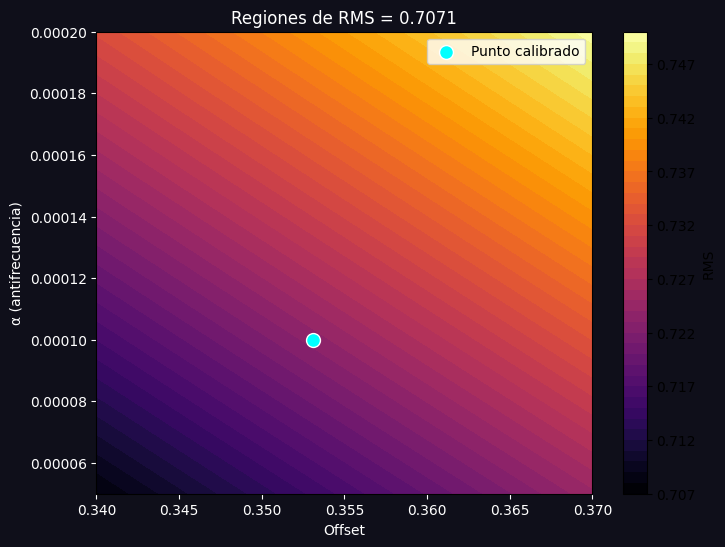

In [2]:
"""
================================================================================
MAPA DE OPERACIÓN: OFFSET vs α (ANTIFRECUENCIA)
================================================================================
"""
import numpy as np
import matplotlib.pyplot as plt

F_TARGET = 232.04
TAU = 0.3697
ROTACION_MESA = 0.07
FS = 16384
DURACION = 3.3
COHERENCIA_FIB = 0.999616
A_OPT = 0.95
TAU_RISE_OPT = 0.15

LAMBDA = -1.0 / F_TARGET
ABS_LAMBDA = np.abs(LAMBDA)

def calcular_rms(offset, alpha_anti):
    t = np.arange(0, DURACION, 1/FS)
    fases = np.arange(8) * np.pi / 4
    factor_anti = 1.0 + np.tanh(alpha_anti / ABS_LAMBDA)

    senal_union = np.zeros_like(t)
    for i, phi in enumerate(fases):
        fase_ajustada = phi - (i * ROTACION_MESA)
        fase_total = 2 * np.pi * F_TARGET * t + fase_ajustada + TAU * np.log(t + 1e-9)
        senal_union += factor_anti * np.sin(fase_total)

    ganancia_t = A_OPT * (1 - np.exp(-t / TAU_RISE_OPT)) + offset
    senal_central = -senal_union * ganancia_t * COHERENCIA_FIB
    return np.sqrt(np.mean(np.abs(senal_central)**2))

# Malla de parámetros
offsets = np.linspace(0.34, 0.37, 30)
alphas = np.linspace(0.00005, 0.00020, 30)
O, A = np.meshgrid(offsets, alphas)
R = np.zeros_like(O)

for i in range(len(alphas)):
    for j in range(len(offsets)):
        R[i, j] = calcular_rms(offsets[j], alphas[i])

# Contorno
plt.figure(figsize=(8,6), facecolor='#0f0f1a')
cont = plt.contourf(O, A, R, levels=50, cmap='inferno')
plt.colorbar(cont, label='RMS')
plt.contour(O, A, R, levels=[0.7071], colors='lime', linewidths=2, linestyles='--')
plt.scatter(0.3531, 0.0001, color='cyan', s=100, edgecolor='white', zorder=5, label='Punto calibrado')
plt.xlabel('Offset', color='white')
plt.ylabel('α (antifrecuencia)', color='white')
plt.title('Regiones de RMS = 0.7071', color='white')
plt.tick_params(colors='white')
plt.legend()
plt.show()